## Quick Start: Convert A MATLAB File

This is the shortest path for converting `HPPC_MultiSine_F10.mat` to a BDS CSV with automatic JSON and PDF reports.

In [26]:
from pathlib import Path
import battery_data_standard as bds
import polars as pl

input_path = Path("HPPC_MultiSine_F10.mat")
output_csv = Path("HPPC_MultiSine_F10.bds.csv")

report = bds.convert(
    input_path,
    output_csv,
    cycler="auto",
    current_sign="preserve",
    report_path="auto",
)

print("Valid:", report.validation.valid)
print("Rows:", report.rows)
print("Report files:", report.metadata.get("report_outputs", {}))

pl.read_csv(output_csv).head(10)

Valid: True
Rows: 71309
Report files: {'json': 'HPPC_MultiSine_F10.bds.report.json', 'pdf': 'HPPC_MultiSine_F10.bds.report.pdf'}


Record Index,Test Time (s),Voltage (V),Current (A),Cycle Count,Step Index,Power (W),Ambient Temperature (degC)
i64,f64,f64,f64,i64,i64,f64,f64
1,0.0,4.198864,0.0,1,9,0.0,22.903685
2,0.9998,4.198934,0.0,1,9,0.0,22.903685
3,1.9998,4.198728,0.0,1,9,0.0,22.909904
4,3.0001,4.198631,0.0,1,9,0.0,22.909904
5,3.9993,4.198592,0.0,1,9,0.0,22.909904
6,5.0002,4.19857,0.0,1,9,0.0,22.91086
7,5.9998,4.198684,0.0,1,9,0.0,22.91086
8,7.0004,4.198559,0.0,1,9,0.0,22.885546
9,7.9992,4.198539,0.0,1,9,0.0,22.885546




---



## Detailed Walkthrough

# BDS 0.2.2 Walkthrough: HPPC MultiSine MATLAB Dataset

This notebook tests `battery-data-standard` on one MATLAB fixture:

`HPPC_MultiSine_F10.mat`

Dataset:
Piombo, G., Fasolato, S., Heymer, R., Hidalgo, M. F., Faraji Niri, M.,
Raimondo, D. M., Marco, J., & Onori, S. (2024).
Full factorial design of experiments dataset for parallel-connected lithium-ion
cells imbalanced performance investigation. Mendeley Data, Version 2.
https://doi.org/10.17632/zh58byr53c.2


The workflow demonstrates fast MATLAB conversion, detection, explain diagnostics,
normalized reading, validation, conversion reports, export files, and quick visual checks.

## 1. Install BDS 0.2.1 With MATLAB Support

In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "battery-data-standard[matlab]==0.2.1",
    "matplotlib",
])

0

## 2. Import Packages And Check Version

In [3]:
from pathlib import Path
import json
import sys
import subprocess

import battery_data_standard as bds
import polars as pl

print("Python:", sys.version)
print("BDS version:", bds.__version__)
assert bds.__version__ == "0.2.1"

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
BDS version: 0.2.1


## 3. Locate Or Upload The Input File

In Colab, upload `HPPC_MultiSine_F10.mat` when prompted.

If running locally on Windows, the notebook will use:

`HPPC_MultiSine_F10.mat`

In [4]:
local_windows_path = Path(r"C:\work\Batterydatastandard\tests\HPPC_MultiSine_F10.mat")
colab_uploaded_path = Path("HPPC_MultiSine_F10.mat")

if local_windows_path.exists():
    input_path = local_windows_path
elif colab_uploaded_path.exists():
    input_path = colab_uploaded_path
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        input_path = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            "Upload HPPC_MultiSine_F10.mat to Colab or update input_path manually."
        ) from exc

print("Input path:", input_path)
print("Input exists:", input_path.exists())
print("Input size MB:", round(input_path.stat().st_size / 1_000_000, 3))

Input path: HPPC_MultiSine_F10.mat
Input exists: True
Input size MB: 0.515


## 4. Create Output Directory

In [5]:
output_dir = Path("bds_outputs") / "hppc_multisine_f10"
output_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir.resolve())

Output directory: /content/bds_outputs/hppc_multisine_f10


## 5. Detect Data Kind

`detect_kind()` decides whether the file is time-series, EIS, unsupported helper content, or unknown.

In [6]:
kind = bds.detect_kind(input_path)

print("Kind:", kind.kind)
print("Confidence:", kind.confidence)
print("Reason:", kind.reason)
print("Path:", kind.path)

Kind: timeseries
Confidence: 0.8
Reason: time, voltage, and current-like columns detected
Path: HPPC_MultiSine_F10.mat


## 6. Detect Adapter

This MATLAB file is expected to route through the generic adapter because it contains recognizable time, voltage, current, cycle, step, and temperature vectors.

In [7]:
detection = bds.detect(input_path)

print("Adapter:", detection.cycler)
print("Confidence:", detection.confidence)
print("Reason:", detection.reason)
print("Candidates:", detection.candidates)

Adapter: generic
Confidence: 0.4
Reason: generic column-token match
Candidates: [{'cycler': 'generic', 'confidence': 0.4, 'reason': 'generic column-token match'}, {'cycler': 'neware', 'confidence': 0.0, 'reason': 'no NEWARE signature'}, {'cycler': 'arbin', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'maccor', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'biologic', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'repower', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'pec', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'novonix', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'basytec', 'confidence': 0.0, 'reason': 'extension fallback'}, {'cycler': 'landt', 'confidence': 0.0, 'reason': 'extension fallback'}]


## 7. Explain The Conversion

`bds.explain()` shows what BDS thinks the file is, which columns map to canonical fields, what warnings were produced, and the recommended next action.

In [8]:
explain_report = bds.explain(
    input_path,
    current_sign="preserve",
    repair_policy="warn",
)

print(explain_report.to_text())

BDS explain
Input: HPPC_MultiSine_F10.mat
Status: ok
Data kind: timeseries (0.8)
Adapter: generic (0.4)
Current sign: preserve
Current sign evidence: raw current mapped without explicit charge/discharge sign evidence
Validation valid: True
Time sampling: irregular-interval
Validation issues:
- missing-optional-column: Optional column unix_time_s is absent.
- missing-optional-column: Optional column date_time is absent.
- missing-optional-column: Optional column record_index is absent.
- missing-optional-column: Optional column step_time_s is absent.
- missing-optional-column: Optional column temperature_t1_deg_c is absent.
- missing-optional-column: Optional column charge_capacity_ah is absent.
- missing-optional-column: Optional column discharge_capacity_ah is absent.
- missing-optional-column: Optional column charge_energy_wh is absent.
Column mapping:
- Time -> test_time_s -> Test Time (s) [numeric]
- Voltage -> voltage_v -> Voltage (V) [numeric]
- Current -> current_a -> Current (A

## 8. Inspect Column Mapping

BDS maps each source column into an internal canonical field, then into a user-facing export column.

In [9]:
payload = explain_report.to_dict()

for item in payload.get("column_mapping", []):
    source = item.get("source")
    source_unit = item.get("source_unit")
    canonical = item.get("canonical_column")
    export = item.get("export_column")
    transform = item.get("transform")
    dtype = item.get("dtype")

    print(f"{source} ({source_unit}) -> {canonical} -> {export} [{dtype}]")
    if transform:
        print("  transform:", transform)

Time (None) -> test_time_s -> Test Time (s) [None]
  transform: numeric
Voltage (None) -> voltage_v -> Voltage (V) [None]
  transform: numeric
Current (None) -> current_a -> Current (A) [None]
  transform: numeric
Cycle (None) -> cycle_index -> Cycle Count [None]
  transform: integer
Step (None) -> step_index -> Step Index [None]
  transform: integer
Temperature (None) -> ambient_temperature_deg_c -> Ambient Temperature (degC) [None]
  transform: numeric
voltage_v|current_a (None) -> power_w -> Power (W) [None]
  transform: V * I


## 9. Save Explain Reports

Write JSON, HTML, Excel, and PDF diagnostic reports.

In [10]:
explain_paths = bds.write_explain_reports(
    explain_report,
    output_dir,
    formats=("json", "html", "xlsx", "pdf"),
    stem="hppc_multisine_f10_explain",
)

for fmt, path in explain_paths.items():
    print(fmt, "->", path)

json -> bds_outputs/hppc_multisine_f10/hppc_multisine_f10_explain.report.json
html -> bds_outputs/hppc_multisine_f10/hppc_multisine_f10_explain.report.html
xlsx -> bds_outputs/hppc_multisine_f10/hppc_multisine_f10_explain.report.xlsx
pdf -> bds_outputs/hppc_multisine_f10/hppc_multisine_f10_explain.report.pdf


## 10. Read Normalized Data With Report

`read_with_report()` returns the normalized canonical dataframe and a conversion report object.

In [11]:
df, report = bds.read_with_report(
    input_path,
    cycler="auto",
    current_sign="preserve",
    repair_policy="warn",
    time_sampling_policy="warn",
)

print("Rows:", df.height)
print("Columns:", df.columns)
print("Adapter:", report.cycler)
print("Valid:", report.validation.valid)
print("Warnings:", report.warnings)

df.head(10)

Rows: 71309
Columns: ['test_time_s', 'voltage_v', 'current_a', 'cycle_index', 'step_index', 'ambient_temperature_deg_c', 'power_w']
Adapter: generic
Valid: True
Warnings: []


test_time_s,voltage_v,current_a,cycle_index,step_index,ambient_temperature_deg_c,power_w
f64,f64,f64,i64,i64,f64,f64
0.0,4.198864,0.0,1,9,22.903685,0.0
0.9998,4.198934,0.0,1,9,22.903685,0.0
1.9998,4.198728,0.0,1,9,22.909904,0.0
3.0001,4.198631,0.0,1,9,22.909904,0.0
3.9993,4.198592,0.0,1,9,22.909904,0.0
5.0002,4.19857,0.0,1,9,22.91086,0.0
5.9998,4.198684,0.0,1,9,22.91086,0.0
7.0004,4.198559,0.0,1,9,22.885546,0.0
7.9992,4.198539,0.0,1,9,22.885546,0.0


## 11. Check Canonical Columns

The normalized internal table should contain machine-readable canonical columns.

In [12]:
expected_columns = [
    "test_time_s",
    "voltage_v",
    "current_a",
    "cycle_index",
    "step_index",
    "ambient_temperature_deg_c",
]

for column in expected_columns:
    print(column, column in df.columns)

df.select([column for column in expected_columns if column in df.columns]).head(10)

test_time_s True
voltage_v True
current_a True
cycle_index True
step_index True
ambient_temperature_deg_c True


test_time_s,voltage_v,current_a,cycle_index,step_index,ambient_temperature_deg_c
f64,f64,f64,i64,i64,f64
0.0,4.198864,0.0,1,9,22.903685
0.9998,4.198934,0.0,1,9,22.903685
1.9998,4.198728,0.0,1,9,22.909904
3.0001,4.198631,0.0,1,9,22.909904
3.9993,4.198592,0.0,1,9,22.909904
5.0002,4.19857,0.0,1,9,22.91086
5.9998,4.198684,0.0,1,9,22.91086
7.0004,4.198559,0.0,1,9,22.885546
7.9992,4.198539,0.0,1,9,22.885546


## 12. Validate The Normalized Data

In [13]:
validation = bds.validate(df, strict=True)

print("Valid:", validation.valid)
print("Schema:", validation.schema_version)
print("Rows:", validation.rows)

if validation.issues:
    for issue in validation.issues:
        print(issue.to_dict())
else:
    print("No validation issues.")

Valid: True
Schema: bds-2026-05
Rows: 71309
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column unix_time_s is absent.', 'column': 'unix_time_s'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column date_time is absent.', 'column': 'date_time'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column record_index is absent.', 'column': 'record_index'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column step_time_s is absent.', 'column': 'step_time_s'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column temperature_t1_deg_c is absent.', 'column': 'temperature_t1_deg_c'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column charge_capacity_ah is absent.', 'column': 'charge_capacity_ah'}
{'level': 'warning', 'code': 'missing-optional-column', 'message': 'Optional column discharge_capacity_ah is absent.', 'co

## 13. Inspect Time Sampling

The HPPC/MultiSine protocol may have irregular time intervals. BDS reports this in `metadata["time_sampling"]`.

In [14]:
time_sampling = report.metadata.get("time_sampling")

print(json.dumps(time_sampling, indent=2))

{
  "policy": "warn",
  "interpolation_method": "linear",
  "tolerance_fraction": 0.1,
  "expected_interval_s": 0.1,
  "status": "irregular-interval",
  "original_rows": 71309,
  "output_rows": 71309,
  "interval_confidence": 0.47318673921579624
}


## 14. Convert To BDS Export With Automatic Reports

`report_path="auto"` writes the converted data plus JSON and PDF reports.

In [15]:
bds_csv = output_dir / "HPPC_MultiSine_F10.bds.csv"

conversion_report = bds.convert(
    input_path,
    bds_csv,
    cycler="auto",
    current_sign="preserve",
    repair_policy="warn",
    time_sampling_policy="warn",
    report_path="auto",
)

print("BDS CSV:", bds_csv)
print("Rows:", conversion_report.rows)
print("Valid:", conversion_report.validation.valid)
print("Report outputs:")
print(json.dumps(conversion_report.metadata.get("report_outputs", {}), indent=2))

BDS CSV: bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.bds.csv
Rows: 71309
Valid: True
Report outputs:
{
  "json": "bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.bds.report.json",
  "pdf": "bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.bds.report.pdf"
}


## 15. Read Back The Exported BDS CSV

The exported file uses user-facing column names such as `Test Time (s)`, `Voltage (V)`, and `Current (A)`.

In [16]:
exported = pl.read_csv(bds_csv)

print("Shape:", exported.shape)
print("Columns:")
for column in exported.columns:
    print("-", column)

exported.head(10)

Shape: (71309, 8)
Columns:
- Record Index
- Test Time (s)
- Voltage (V)
- Current (A)
- Cycle Count
- Step Index
- Power (W)
- Ambient Temperature (degC)


Record Index,Test Time (s),Voltage (V),Current (A),Cycle Count,Step Index,Power (W),Ambient Temperature (degC)
i64,f64,f64,f64,i64,i64,f64,f64
1,0.0,4.198864,0.0,1,9,0.0,22.903685
2,0.9998,4.198934,0.0,1,9,0.0,22.903685
3,1.9998,4.198728,0.0,1,9,0.0,22.909904
4,3.0001,4.198631,0.0,1,9,0.0,22.909904
5,3.9993,4.198592,0.0,1,9,0.0,22.909904
6,5.0002,4.19857,0.0,1,9,0.0,22.91086
7,5.9998,4.198684,0.0,1,9,0.0,22.91086
8,7.0004,4.198559,0.0,1,9,0.0,22.885546
9,7.9992,4.198539,0.0,1,9,0.0,22.885546


## 16. Confirm Temperature Export

The MATLAB `Temperature` vector should be exported as `Ambient Temperature (degC)`.

In [17]:
temperature_column = "Ambient Temperature (degC)"

print("Has temperature:", temperature_column in exported.columns)

if temperature_column in exported.columns:
    exported.select([
        "Test Time (s)",
        "Voltage (V)",
        "Current (A)",
        temperature_column,
    ]).head(10)

Has temperature: True


## 17. Convert To Other Export Targets

BDS can also export staging tables for downstream tools.

In [18]:
pyprobe_parquet = output_dir / "HPPC_MultiSine_F10.pyprobe.parquet"
bdf_csv = output_dir / "HPPC_MultiSine_F10.bdf.csv"
polars_parquet = output_dir / "HPPC_MultiSine_F10.polars.parquet"

pyprobe_report = bds.convert(
    input_path,
    pyprobe_parquet,
    cycler="auto",
    current_sign="preserve",
    target="pyprobe",
    format="parquet",
)

bdf_report = bds.convert(
    input_path,
    bdf_csv,
    cycler="auto",
    current_sign="preserve",
    target="bdf",
    format="csv",
)

polars_report = bds.convert(
    input_path,
    polars_parquet,
    cycler="auto",
    current_sign="preserve",
    target="polars",
    format="parquet",
)

print("PyProBE:", pyprobe_parquet, pyprobe_report.validation.valid)
print("BDF:", bdf_csv, bdf_report.validation.valid)
print("Polars:", polars_parquet, polars_report.validation.valid)

PyProBE: bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.pyprobe.parquet True
BDF: bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.bdf.csv True
Polars: bds_outputs/hppc_multisine_f10/HPPC_MultiSine_F10.polars.parquet True


## 18. Quick Numeric Summary

In [19]:
summary_columns = [
    "test_time_s",
    "voltage_v",
    "current_a",
    "cycle_index",
    "step_index",
    "ambient_temperature_deg_c",
    "power_w",
]

available = [column for column in summary_columns if column in df.columns]

df.select(available).describe()

statistic,test_time_s,voltage_v,current_a,cycle_index,step_index,ambient_temperature_deg_c,power_w
str,f64,f64,f64,f64,f64,f64,f64
"""count""",71309.0,71309.0,71309.0,71309.0,71309.0,71309.0,71309.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",21502.482941,3.737824,-0.2293,4.859877,14.074731,23.16435,-0.798349
"""std""",11651.143894,0.256156,1.694699,2.637071,4.212685,0.491359,6.165202
"""min""",0.0,3.036493,-19.298813,1.0,9.0,22.733564,-73.597995
"""25%""",10611.091196,3.567146,0.0,3.0,11.0,22.918184,0.0
"""50%""",21701.765708,3.732242,0.0,5.0,11.0,23.018742,0.0
"""75%""",31913.089908,3.925915,0.0,7.0,15.0,23.155317,0.0
"""max""",40822.943656,4.198934,6.72876,9.0,22.0,27.121838,26.276237


## 19. Plot Voltage, Current, And Temperature

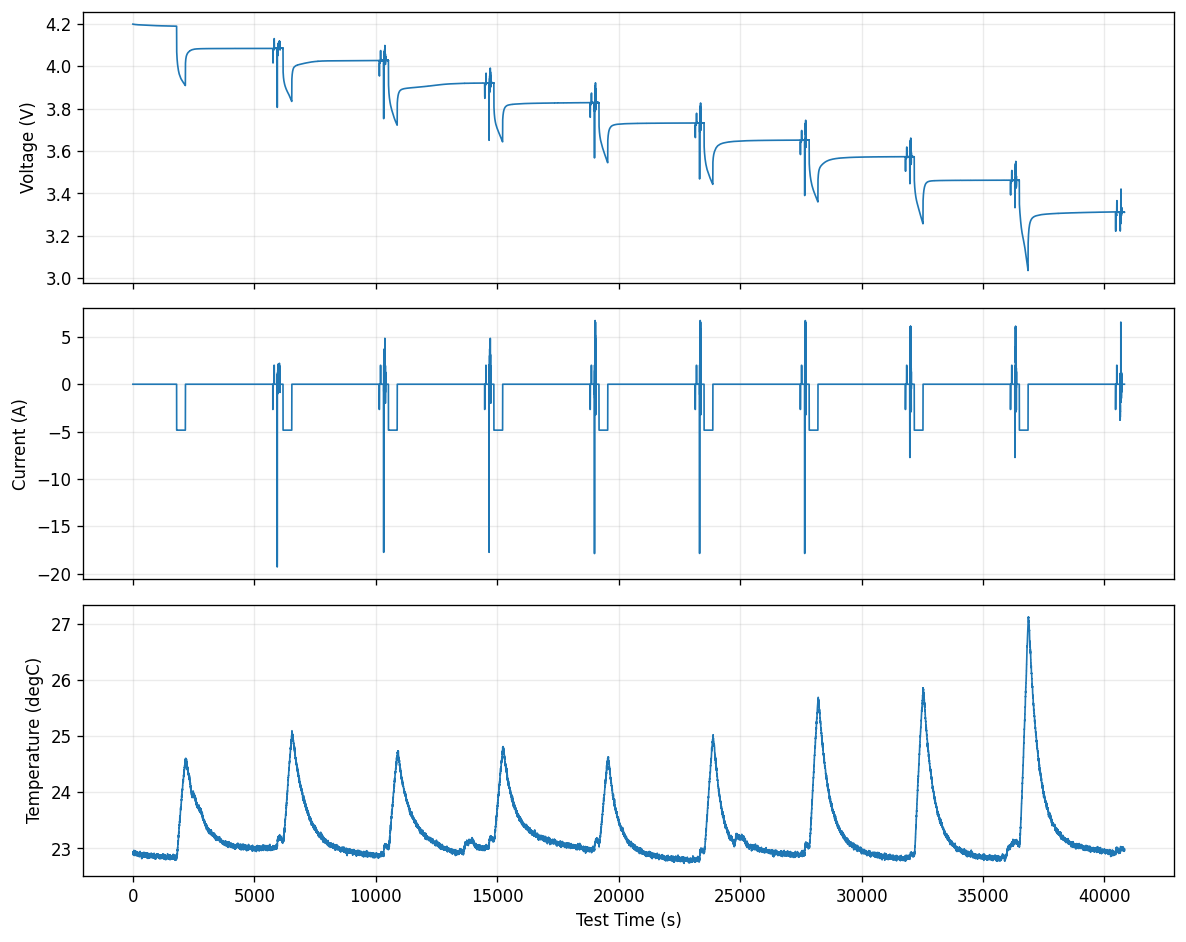

In [20]:
import matplotlib.pyplot as plt

plot_df = df.select([
    column for column in [
        "test_time_s",
        "voltage_v",
        "current_a",
        "ambient_temperature_deg_c",
    ]
    if column in df.columns
]).to_pandas()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, dpi=120)

axes[0].plot(plot_df["test_time_s"], plot_df["voltage_v"], linewidth=1)
axes[0].set_ylabel("Voltage (V)")
axes[0].grid(True, alpha=0.25)

axes[1].plot(plot_df["test_time_s"], plot_df["current_a"], linewidth=1)
axes[1].set_ylabel("Current (A)")
axes[1].grid(True, alpha=0.25)

if "ambient_temperature_deg_c" in plot_df.columns:
    axes[2].plot(plot_df["test_time_s"], plot_df["ambient_temperature_deg_c"], linewidth=1)
    axes[2].set_ylabel("Temperature (degC)")
else:
    axes[2].text(0.5, 0.5, "No temperature column", ha="center", va="center")
    axes[2].set_ylabel("Temperature")

axes[2].set_xlabel("Test Time (s)")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 20. Plot One Cycle Or Step

This helps inspect whether cycle and step labels are usable.

In [21]:
if "cycle_index" in df.columns:
    cycles = df["cycle_index"].drop_nulls().unique().sort().to_list()
    print("Cycles:", cycles[:20])
else:
    cycles = []

if "step_index" in df.columns:
    steps = df["step_index"].drop_nulls().unique().sort().to_list()
    print("Steps:", steps[:20])
else:
    steps = []

Cycles: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Steps: [9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22]


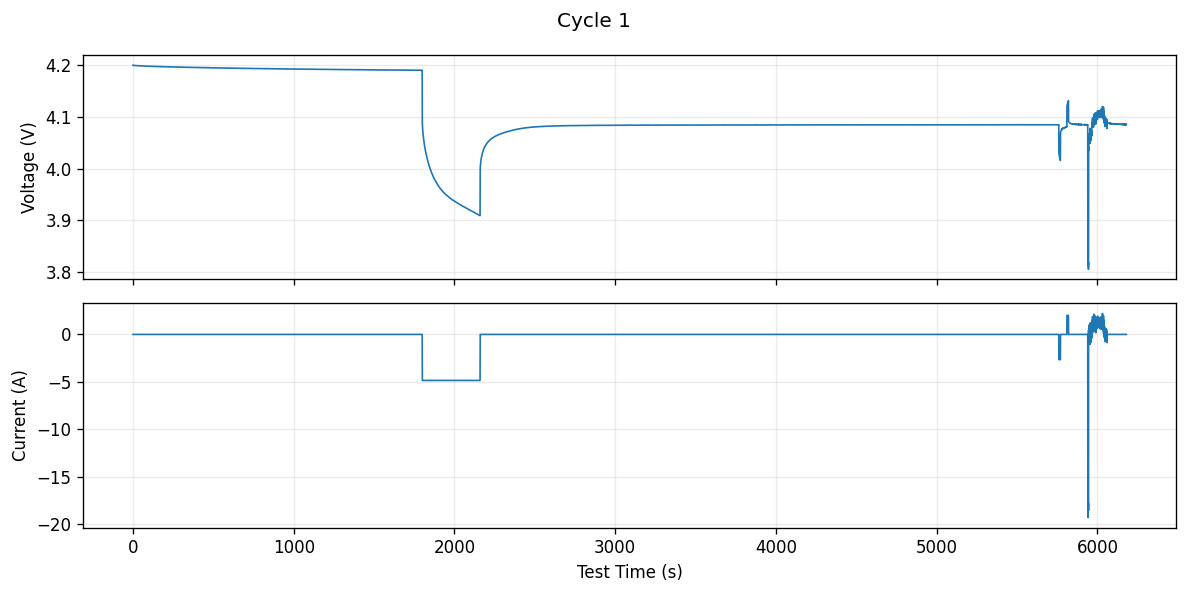

In [22]:
if "cycle_index" in df.columns and cycles:
    selected_cycle = cycles[0]
    cycle_df = df.filter(pl.col("cycle_index") == selected_cycle)

    plot_cycle = cycle_df.select([
        "test_time_s",
        "voltage_v",
        "current_a",
    ]).to_pandas()

    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, dpi=120)
    axes[0].plot(plot_cycle["test_time_s"], plot_cycle["voltage_v"], linewidth=1)
    axes[0].set_ylabel("Voltage (V)")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(plot_cycle["test_time_s"], plot_cycle["current_a"], linewidth=1)
    axes[1].set_ylabel("Current (A)")
    axes[1].set_xlabel("Test Time (s)")
    axes[1].grid(True, alpha=0.25)

    fig.suptitle(f"Cycle {selected_cycle}")
    plt.tight_layout()
    plt.show()
else:
    print("No cycle_index column available.")

## 21. CLI Parity

Run the same diagnostic through the command line.

In [23]:
cli_json = output_dir / "hppc_multisine_f10_cli_explain.json"
cli_html = output_dir / "hppc_multisine_f10_cli_explain.html"
cli_xlsx = output_dir / "hppc_multisine_f10_cli_explain.xlsx"
cli_pdf = output_dir / "hppc_multisine_f10_cli_explain.pdf"

cmd = [
    sys.executable,
    "-m",
    "battery_data_standard.cli",
    "explain",
    str(input_path),
    "--current-sign",
    "preserve",
    "--json",
    str(cli_json),
    "--html",
    str(cli_html),
    "--xlsx",
    str(cli_xlsx),
    "--pdf",
    str(cli_pdf),
]

run = subprocess.run(cmd, text=True, capture_output=True, check=True)

print(run.stdout[:2000])
print("JSON exists:", cli_json.exists())
print("HTML exists:", cli_html.exists())
print("XLSX exists:", cli_xlsx.exists())
print("PDF exists:", cli_pdf.exists())

{
  "input_path": "HPPC_MultiSine_F10.mat",
  "status": "ok",
  "data_kind": {
    "kind": "timeseries",
    "confidence": 0.8,
    "reason": "time, voltage, and current-like columns detected",
    "path": "HPPC_MultiSine_F10.mat",
    "evidence": {
      "columns": [
        "Time",
        "Voltage",
        "Current",
        "Cycle",
        "Step",
        "Temperature"
      ]
    }
  },
  "detection": {
    "cycler": "generic",
    "confidence": 0.4,
    "reason": "generic column-token match",
    "candidates": [
      {
        "cycler": "generic",
        "confidence": 0.4,
        "reason": "generic column-token match"
      },
      {
        "cycler": "neware",
        "confidence": 0.0,
        "reason": "no NEWARE signature"
      },
      {
        "cycler": "arbin",
        "confidence": 0.0,
        "reason": "extension fallback"
      },
      {
        "cycler": "maccor",
        "confidence": 0.0,
        "reason": "extension fallback"
      },
      {
        "cycl

## 23. Download Outputs From Colab

Run this cell only in Colab if you want to download the generated files.

In [24]:
try:
    from google.colab import files
    import shutil

    archive_path = shutil.make_archive(str(output_dir), "zip", output_dir)
    files.download(archive_path)
except Exception as exc:
    print("Download helper is only available in Colab.")
    print(exc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>